### Machine Learning with Scikit-learn: SVM Classification Example

We are using the [phishing](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary.html) dataset

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
from scipy.sparse import csr_matrix

### Read the data

In [33]:
from sklearn.datasets import load_svmlight_file

# Load the dataset 
X, T = load_svmlight_file("phishing.txt")

In [34]:
print(X.shape)
print(np.unique(T))

(11055, 68)
[0. 1.]


In [35]:
print('Num of Positive:', len(np.where(T==1)[0]))
print('Num of Negative:', len(np.where(T==0)[0]))

Num of Positive: 6157
Num of Negative: 4898


### Split the data into training and test sets

In [36]:
X_train, X_test, T_train, T_test = train_test_split(X, T, test_size=0.2, random_state=42, stratify= T)

### Preprocess / Scale the features

In [37]:
scaler = StandardScaler()
scaler = MinMaxScaler()
scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
print(f'{X_train.shape = }')
#print(f'{X_val.shape = }')
print(f'{X_test.shape = }')


X_train.shape = (8844, 68)
X_test.shape = (2211, 68)


## Model Selection

In [39]:

from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC


C = [10,1,0.5,0.1]

skf = StratifiedKFold(n_splits=3)

acc = np.empty((3,len(C)))

for i, (train_index, test_index) in enumerate(skf.split(X_train, T_train)):

    xtrain = X_train[train_index]
    ttrain = T_train[train_index]
    
    xtest = X_train[test_index]
    ttest = T_train[test_index]

    for j in range(len(C)):
        
        model = SVC(kernel = 'rbf', C=C[j]) 
        
        model.fit(xtrain, ttrain)

        pred = model.predict(xtest)

        acc[i,j] = accuracy_score(ttest, pred)
        

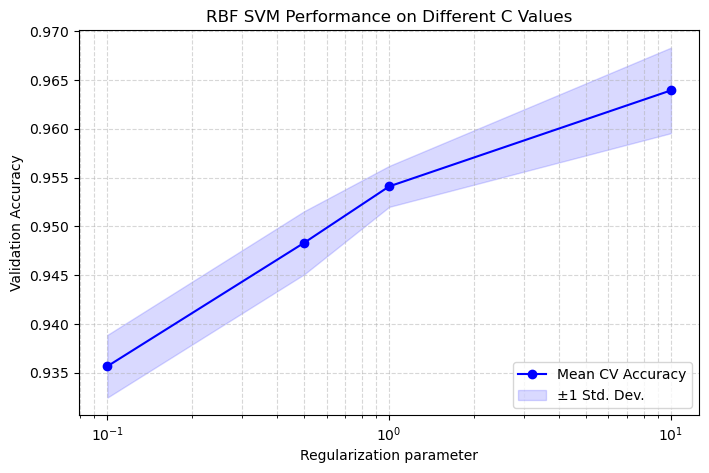

In [40]:

mean_accuracies = np.mean(acc, axis=0)
std_accuracies = np.std(acc, axis=0)

plt.figure(figsize=(8, 5))

plt.plot(C, mean_accuracies, marker='o', linestyle='-', color='b', label='Mean CV Accuracy')

plt.fill_between(C, 
                 mean_accuracies - std_accuracies, 
                 mean_accuracies + std_accuracies, 
                 alpha=0.15, color='b', label='±1 Std. Dev.')

plt.xscale('log')
plt.xlabel('Regularization parameter')
plt.ylabel('Validation Accuracy')
plt.title('RBF SVM Performance on Different C Values')
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(loc='lower right')

plt.show()


In [41]:
acc

array([[0.96268657, 0.95522388, 0.95183175, 0.93622795],
       [0.95929444, 0.95115332, 0.94402985, 0.93147897],
       [0.96981004, 0.95590231, 0.94911805, 0.93928087]])

In [42]:
avg_acc = np.mean(acc, axis = 0)
idx = np.argmax(avg_acc)
print(f'best C = {C[idx]}')

best_C = C[idx] 

best C = 10


## Train the best model

In [43]:
model = SVC(kernel = 'rbf', C=C[j]) 
        
model.fit(X_train, T_train)


,C,0.1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Test the best model

In [44]:
pred = model.predict(X_test)

acc = accuracy_score(T_test, pred, normalize=True)

print(f'Accuracy = {acc*100:.2f}%')

Accuracy = 93.98%
